# How large can my memory be while still maintaining less control resources than a memory-less system

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
import os

fig_dir = os.path.join(os.path.dirname(os.path.abspath('2603_craqm_mm2026_talk.ipynb')), 
                       'figures', 'craqm_mm2026')
os.makedirs(fig_dir, exist_ok=True)
print(f"Figures will be saved to: {fig_dir}")

Figures will be saved to: /Users/eesh/Documents/multimode_sims/theory/figures/craqm_mm2026


# RAM Surface Code Scaling with coherence time 
Consider gate time, and mode coherence

error correction cycle length \(t_{log}\). main error
error on physical qubit $$p = \frac{t_{log}}{T_{\text{coh},qub}}$$
error on memory $$p_{mem,idle} =  \frac{(N-1) *( t_{log} + 2t_{swap})}{T_{\text{coh},mem}}  $$
error on memory swap $$p_{mem, gate} = t_{swap}*(\frac{1}{T_{\text{coh}, mem}} + \frac{1}{T_{\text{coh}, qub}})$$
$$$$

Plots 
x axis: t1 qub
y axis : t1 mem 
z axis: lower bound on number of raqm/ upper 
two of these plots 

at error rate 1e-10

## Remember fundamental equations 
### memory less system 
$$\varepsilon = \left(\frac{p  }{p_{\text{threshold}}}\right)^{\frac{D+1}{2}}$$
### memory full system 
$$\varepsilon' = \left(\frac{p + p_{mem}}{p_{\text{threshold}}}\right)^{\frac{D'+1}{2}}$$

### Comparison of resources 
r = 5 (z + x for data and ancilla + readout)
Condition for memory efficiency
$$(r+1)D'^2 <rND^2$$
Define memory efficient 
$$eff = \frac{rND^2}{(r+1)D'^2 }$$

## Plotting Idea 
Given T1 of qubit and T1 of memory, I want to plot the max efficiency achievable with those parameters. So that is one 2d colorplot. This is main plot 

Then I want some additional colorplots tracking N_optimal, ratio of code distances D'/D, ratio of error fractions (p_mem/p_memth  over p_q/p_qth). 

Finally, i want to also generate plots showing that for a specific T1 pairing, showing efficiency as a function of number of modes N 

In [17]:
#

## Full Parameter Space

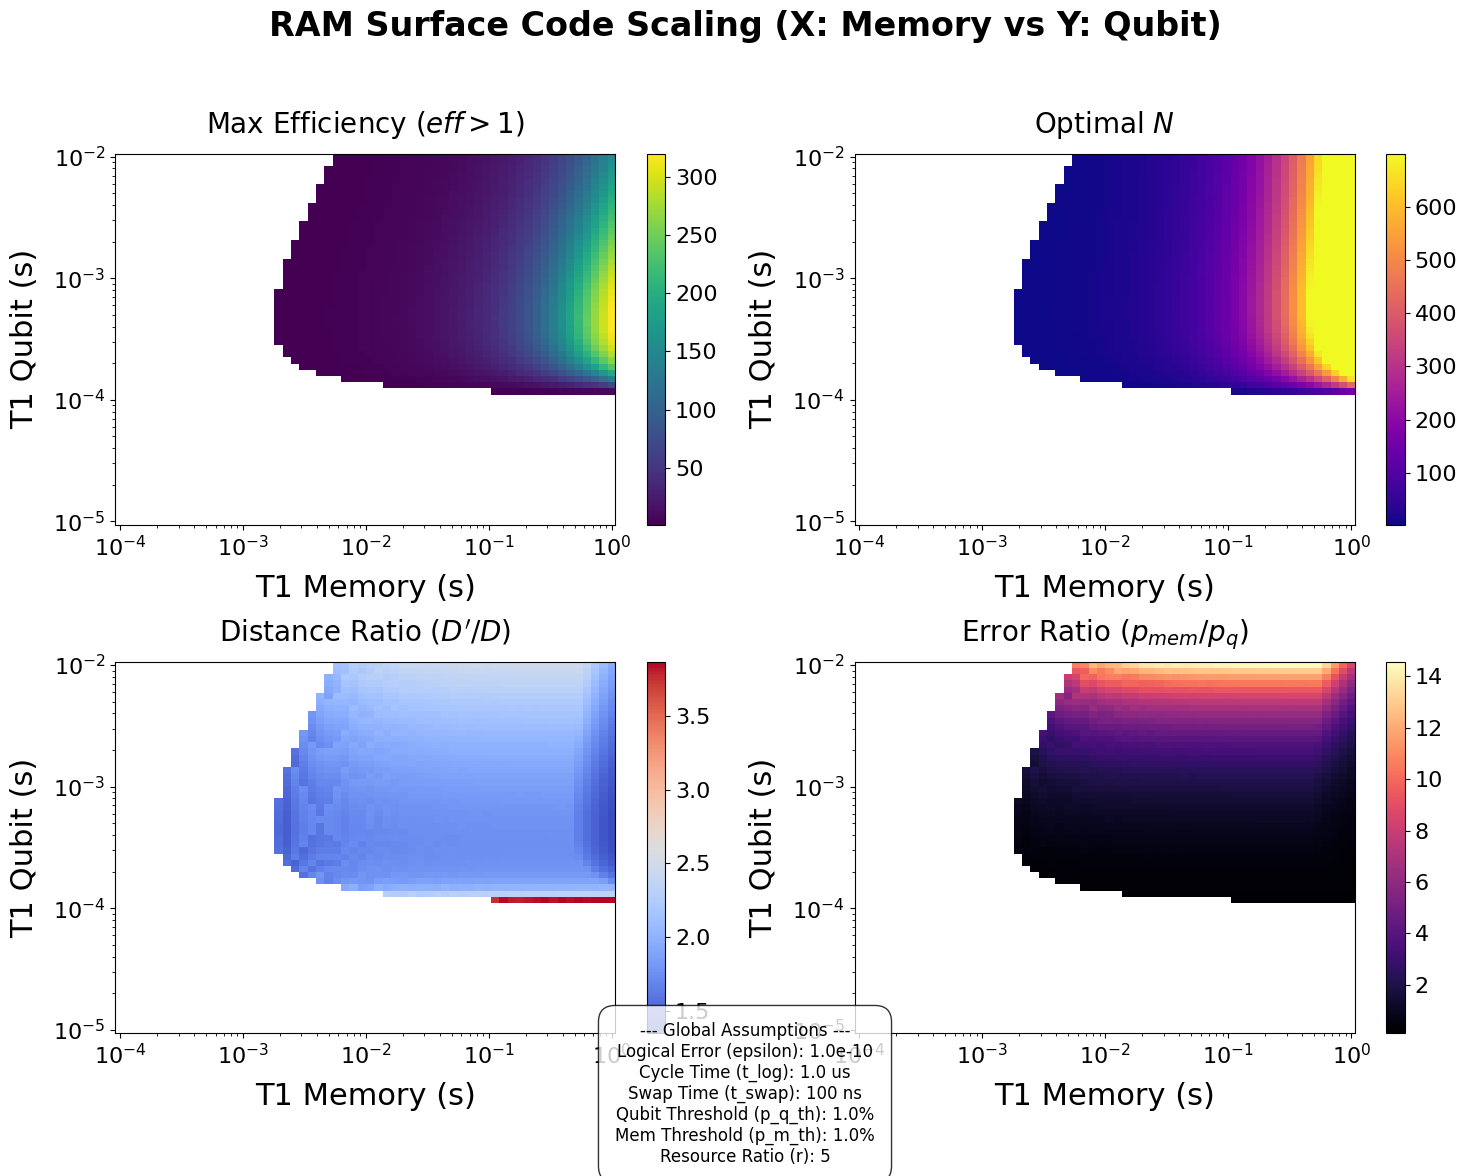

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def get_d(vareps, p_ratio):
    if p_ratio >= 1.0 or p_ratio <= 0:
        return np.nan
    d = np.log10(vareps) / np.log10(p_ratio)
    return d if d > 0 else np.nan


def analyze_point(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit, N, 
                  p_q_threshold=0.01, p_mem_threshold=0.01, r=3):
    pq = t_log_cycle / T_coh_qubit
    pm = (t_swap * (1/T_coh_cav + 1/T_coh_qubit)) + \
         ((N - 1) * (t_log_cycle + 2 * t_swap) / T_coh_cav)
    
    pq_ratio = pq / p_q_threshold
    pm_ratio = pm / p_mem_threshold
    
    D = get_d(vareps, pq_ratio)
    Dp = get_d(vareps, pq_ratio + pm_ratio)
    
    if np.isnan(D) or np.isnan(Dp):
        return np.nan, np.nan, np.nan, np.nan
    
    eff = (r * N * D**2) / ((r + 1) * Dp**2)
    return eff, N, Dp/D, pm_ratio/pq_ratio

def sweep_hardware_swapped(vareps, t_log_cycle, t_swap, T1_qub_range, T1_mem_range, 
                           p_q_th, p_m_th, r=5, N_max=300):
    M, Q = np.meshgrid(T1_mem_range, T1_qub_range)
    results = np.full((4, len(T1_qub_range), len(T1_mem_range)), np.nan)

    for i in range(len(T1_qub_range)):
        for j in range(len(T1_mem_range)):
            best_eff = 1.0  
            best_stats = [np.nan] * 4
            for n in range(1, N_max):
                stats = analyze_point(vareps, t_log_cycle, t_swap, M[i,j], Q[i,j], n, 
                                      p_q_threshold=p_q_th, p_mem_threshold=p_m_th, r=r)
                if not np.isnan(stats[0]) and stats[0] > best_eff:
                    best_eff = stats[0]
                    best_stats = stats
            results[:, i, j] = best_stats
    return M, Q, results

# --- Assumptions ---
vareps = 1e-10
t_log = 1e-6    
t_swap = 0.1e-6  # 100 ns
p_q_th = 0.01   
p_m_th = 0.01
r = 5

T1_Q = np.logspace(-5, -2, 60)
T1_M = np.logspace(-4, 0, 60)

M, Q, data = sweep_hardware_swapped(vareps, t_log, t_swap, T1_Q, T1_M, p_q_th, p_m_th, r=5, N_max=700)

# --- Plotting ---
label_size = 22
tick_size = 16
title_size = 20

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
titles = [r'Max Efficiency ($eff > 1$)', 'Optimal $N$', 
          r"Distance Ratio ($D'/D$)", r"Error Ratio ($p_{mem}/p_q$)"]
cmaps = ['viridis', 'plasma', 'coolwarm', 'magma']

for i, ax in enumerate(axs.flatten()):
    im = ax.pcolormesh(M, Q, data[i], shading='auto', cmap=cmaps[i])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(titles[i], fontsize=title_size, pad=15)
    ax.set_xlabel('T1 Memory (s)', fontsize=label_size, labelpad=10)
    ax.set_ylabel('T1 Qubit (s)', fontsize=label_size, labelpad=10)
    ax.tick_params(axis='both', labelsize=tick_size)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=tick_size)

assumption_text = (
    f"--- Global Assumptions ---\n"
    f"Logical Error (epsilon): {vareps:.1e}\n"
    f"Cycle Time (t_log): {t_log*1e6:.1f} us\n"
    f"Swap Time (t_swap): {t_swap*1e9:.0f} ns\n"
    f"Qubit Threshold (p_q_th): {p_q_th*100:.1f}%\n"
    f"Mem Threshold (p_m_th): {p_m_th*100:.1f}%\n"
    f"Resource Ratio (r): {r}"
)
fig.text(0.5, 0.02, assumption_text, ha='center', fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))

plt.suptitle("RAM Surface Code Scaling (X: Memory vs Y: Qubit)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'full_param_space_100ns_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

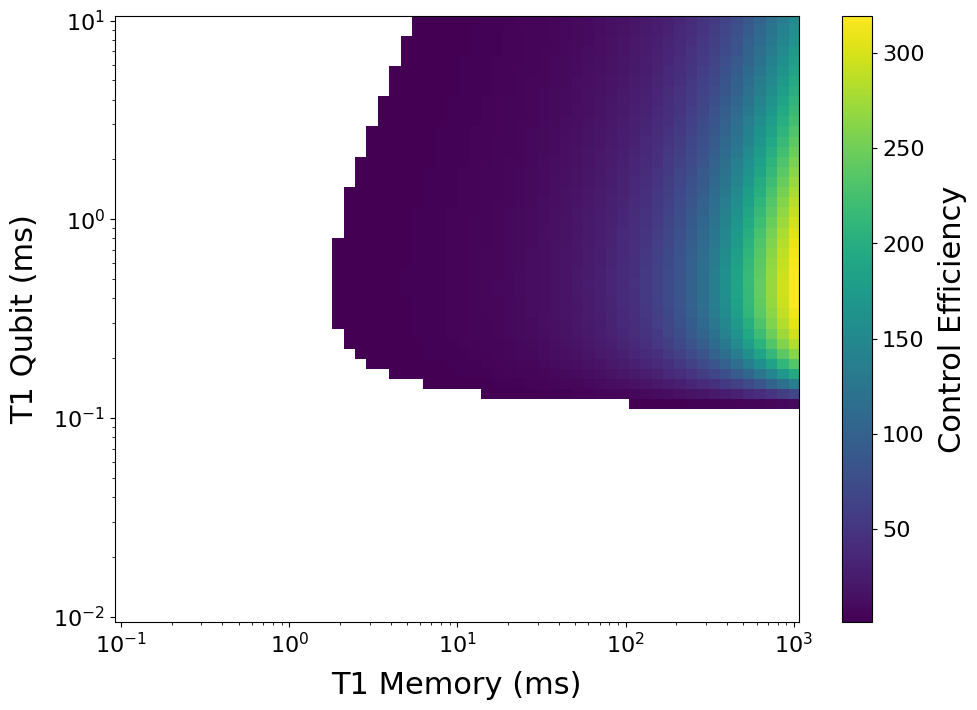

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(10, 8))

label_size = 22
title_size = 24

im = axs.pcolormesh(M*1e3, Q*1e3, data[0], shading='auto', cmap=cmaps[0])
axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlabel('T1 Memory (ms)', fontsize=label_size, labelpad=10)
axs.set_ylabel('T1 Qubit (ms)', fontsize=label_size, labelpad=10)
axs.tick_params(axis='both', labelsize=16)

cbar = fig.colorbar(im, ax=axs)
cbar.set_label('Control Efficiency', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=16) 

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'efficiency_100ns_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## For current swap parameter (2 microsecnds)

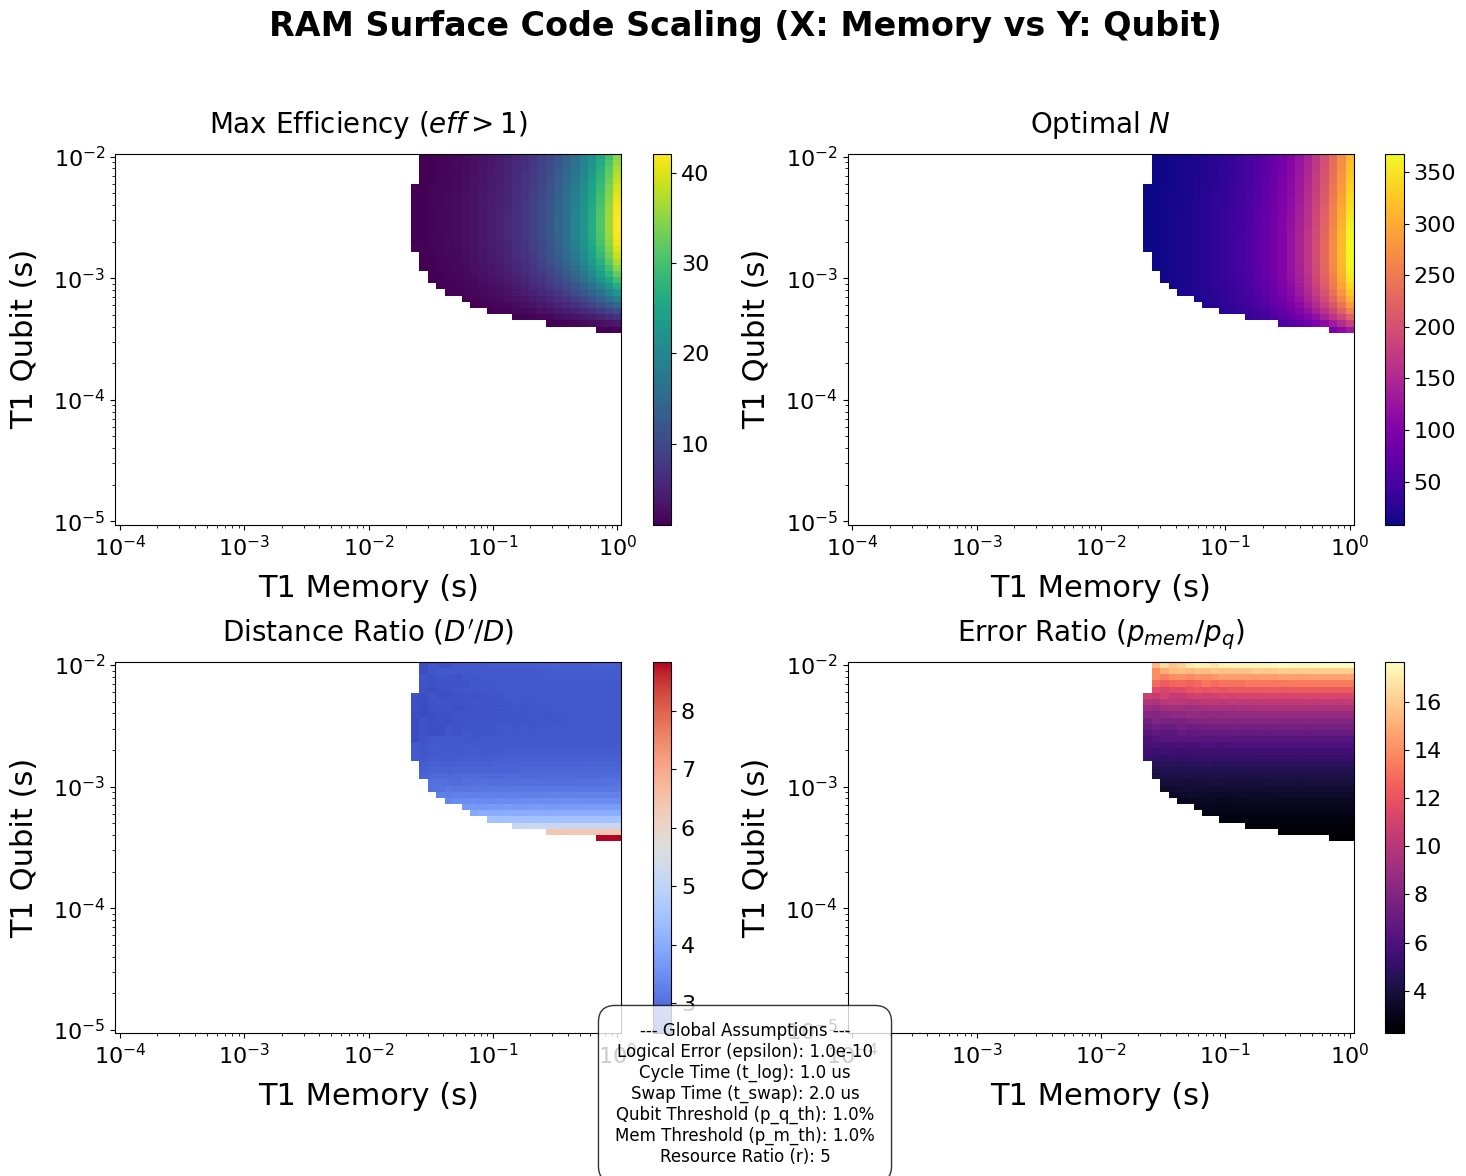

In [26]:
# --- Assumptions ---
vareps = 1e-10
t_log = 1e-6    
t_swap = 2e-6
p_q_th = 0.01   
p_m_th = 0.01
r = 5

T1_Q = np.logspace(-5, -2, 60)
T1_M = np.logspace(-4, 0, 60)


M, Q, data = sweep_hardware_swapped(vareps, t_log, t_swap, T1_Q, T1_M, p_q_th, p_m_th, r=5, N_max=700)

# --- Plotting ---
label_size = 22
tick_size = 16
title_size = 20

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
titles = [r'Max Efficiency ($eff > 1$)', 'Optimal $N$', 
          r"Distance Ratio ($D'/D$)", r"Error Ratio ($p_{mem}/p_q$)"]
cmaps = ['viridis', 'plasma', 'coolwarm', 'magma']

for i, ax in enumerate(axs.flatten()):
    im = ax.pcolormesh(M, Q, data[i], shading='auto', cmap=cmaps[i])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(titles[i], fontsize=title_size, pad=15)
    ax.set_xlabel('T1 Memory (s)', fontsize=label_size, labelpad=10)
    ax.set_ylabel('T1 Qubit (s)', fontsize=label_size, labelpad=10)
    ax.tick_params(axis='both', labelsize=tick_size)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=tick_size)

assumption_text = (
    f"--- Global Assumptions ---\n"
    f"Logical Error (epsilon): {vareps:.1e}\n"
    f"Cycle Time (t_log): {t_log*1e6:.1f} us\n"
    f"Swap Time (t_swap): {t_swap*1e6:.1f} us\n"
    f"Qubit Threshold (p_q_th): {p_q_th*100:.1f}%\n"
    f"Mem Threshold (p_m_th): {p_m_th*100:.1f}%\n"
    f"Resource Ratio (r): {r}"
)
fig.text(0.5, 0.02, assumption_text, ha='center', fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))

plt.suptitle("RAM Surface Code Scaling (X: Memory vs Y: Qubit)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'full_param_space_2us_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

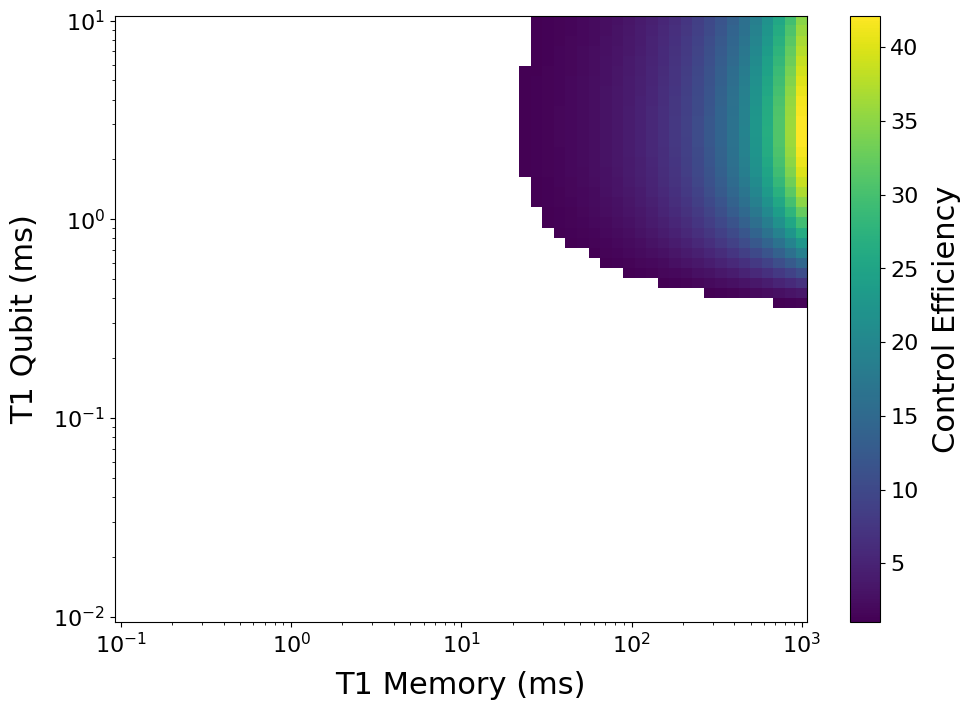

In [28]:
fig, axs = plt.subplots(1, 1, figsize=(10, 8))

label_size = 22
title_size = 24

im = axs.pcolormesh(M*1e3, Q*1e3, data[0], shading='auto', cmap=cmaps[0])
axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlabel('T1 Memory (ms)', fontsize=label_size, labelpad=10)
axs.set_ylabel('T1 Qubit (ms)', fontsize=label_size, labelpad=10)
axs.tick_params(axis='both', labelsize=16)

cbar = fig.colorbar(im, ax=axs)
cbar.set_label('Control Efficiency', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=16) 

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'efficiency_2us_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [22]:
np.min(data[0])

nan

## For current swap parameter (0.5 microsecnds)

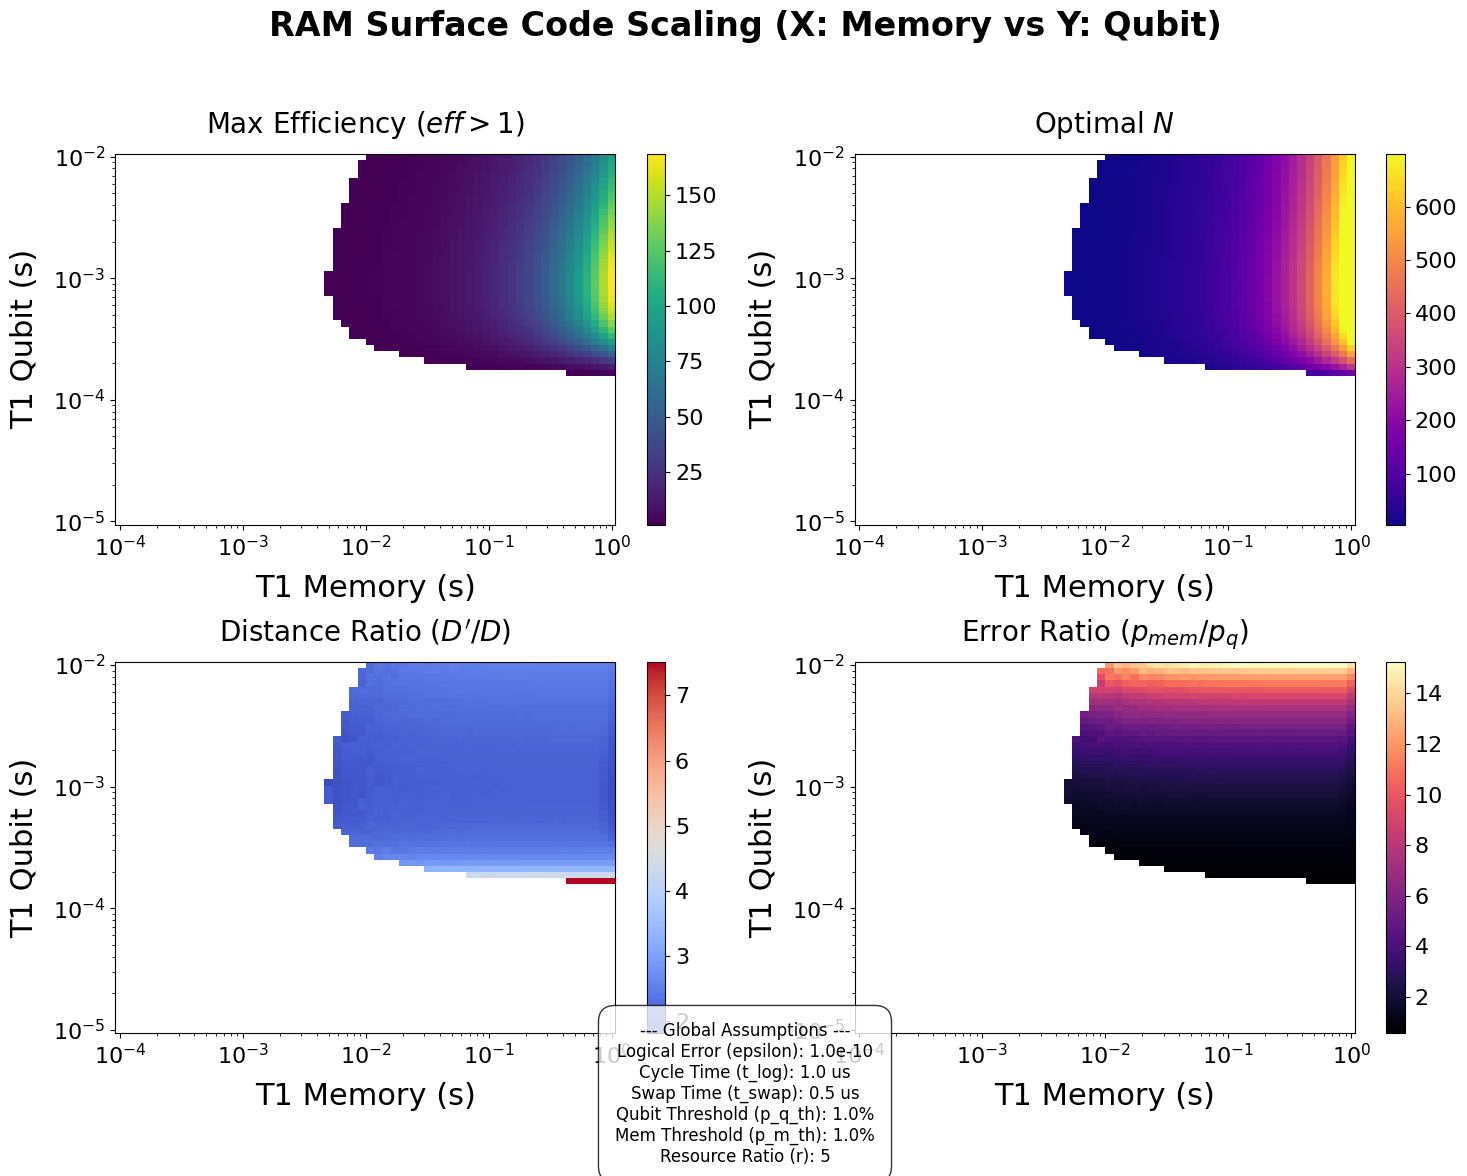

In [29]:
# --- Assumptions ---
vareps = 1e-10
t_log = 1e-6    
t_swap = 0.5e-6
p_q_th = 0.01   
p_m_th = 0.01
r = 5

T1_Q = np.logspace(-5, -2, 60)
T1_M = np.logspace(-4, 0, 60)


M, Q, data = sweep_hardware_swapped(vareps, t_log, t_swap, T1_Q, T1_M, p_q_th, p_m_th, r=5, N_max=700)

# --- Plotting ---
label_size = 22
tick_size = 16
title_size = 20

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
titles = [r'Max Efficiency ($eff > 1$)', 'Optimal $N$', 
          r"Distance Ratio ($D'/D$)", r"Error Ratio ($p_{mem}/p_q$)"]
cmaps = ['viridis', 'plasma', 'coolwarm', 'magma']

for i, ax in enumerate(axs.flatten()):
    im = ax.pcolormesh(M, Q, data[i], shading='auto', cmap=cmaps[i])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(titles[i], fontsize=title_size, pad=15)
    ax.set_xlabel('T1 Memory (s)', fontsize=label_size, labelpad=10)
    ax.set_ylabel('T1 Qubit (s)', fontsize=label_size, labelpad=10)
    ax.tick_params(axis='both', labelsize=tick_size)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=tick_size)

assumption_text = (
    f"--- Global Assumptions ---\n"
    f"Logical Error (epsilon): {vareps:.1e}\n"
    f"Cycle Time (t_log): {t_log*1e6:.1f} us\n"
    f"Swap Time (t_swap): {t_swap*1e6:.1f} us\n"
    f"Qubit Threshold (p_q_th): {p_q_th*100:.1f}%\n"
    f"Mem Threshold (p_m_th): {p_m_th*100:.1f}%\n"
    f"Resource Ratio (r): {r}"
)
fig.text(0.5, 0.02, assumption_text, ha='center', fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))

plt.suptitle("RAM Surface Code Scaling (X: Memory vs Y: Qubit)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'full_param_space_0_5us_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

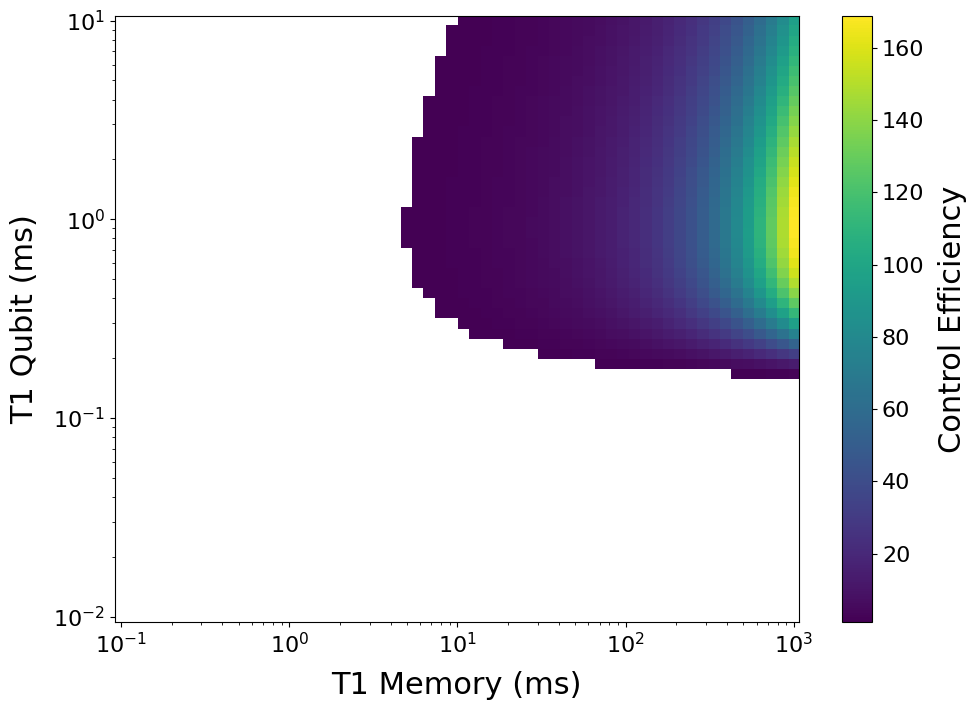

In [30]:
fig, axs = plt.subplots(1, 1, figsize=(10, 8))

label_size = 22
title_size = 24

im = axs.pcolormesh(M*1e3, Q*1e3, data[0], shading='auto', cmap=cmaps[0])
axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlabel('T1 Memory (ms)', fontsize=label_size, labelpad=10)
axs.set_ylabel('T1 Qubit (ms)', fontsize=label_size, labelpad=10)
axs.tick_params(axis='both', labelsize=16)

cbar = fig.colorbar(im, ax=axs)
cbar.set_label('Control Efficiency', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=16) 

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(os.path.join(fig_dir, 'efficiency_0_5us_swap.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## For state of the art parameters

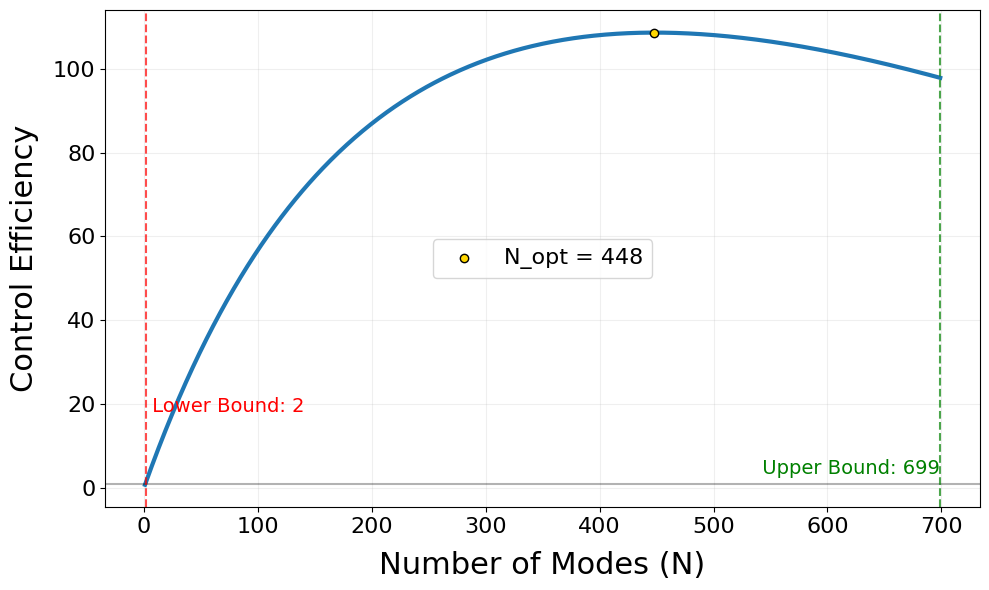

In [33]:
# --- Parameters ---
vareps = 1e-10
t_log = 1e-6
t_swp = 0.1e-6
T1_mem = 300e-3
T1_qub = 1e-3
n_range = np.arange(1, 700)

effs = []
for n in n_range:
    res = analyze_point(vareps, t_log, t_swp, T1_mem, T1_qub, n, 0.01, 0.01, 5)
    effs.append(res[0])

effs = np.array(effs)
advantage_indices = np.where(effs > 1.0)[0]

if len(advantage_indices) > 0:
    n_low = n_range[advantage_indices[0]]
    n_high = n_range[advantage_indices[-1]]
    n_opt = n_range[np.nanargmax(effs)]
else:
    n_low = n_high = n_opt = None

label_size = 22
tick_size = 16

plt.figure(figsize=(10, 6))
plt.plot(n_range, effs, color='tab:blue', lw=3)
plt.axhline(1, color='black', linestyle='-', alpha=0.3)

if n_low is not None:
    plt.axvline(n_low, color='red', linestyle='--', alpha=0.7)
    plt.axvline(n_high, color='green', linestyle='--', alpha=0.7)
    
    plt.text(n_low, plt.ylim()[1]*0.16, f' Lower Bound: {n_low}', color='red', fontsize=14)
    plt.text(n_high, plt.ylim()[1]*0.03, f' Upper Bound: {n_high}', color='green', ha='right', fontsize=14)
    
    plt.scatter(n_opt, np.nanmax(effs), color='gold', edgecolor='black', zorder=5, label=f'N_opt = {n_opt}')

plt.xlabel('Number of Modes (N)', fontsize=label_size, labelpad=10)
plt.ylabel('Control Efficiency', fontsize=label_size, labelpad=10)
plt.tick_params(axis='both', labelsize=tick_size)
plt.grid(True, alpha=0.2)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, 'efficiency_vs_n_sota.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [24]:
np.nanmax(effs)


11.06205461670375

## for different memory Thresholds

<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
/var/folders/qv/2zlrl3v97s9_ht7wrdl_fgp00000gn/T/ipykernel_47447/3402388546.py:39: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Optimal Multiplexing (N*) vs Memory Threshold\n$T_{{1,m}}=10$ms, $T_{{1,q}}=1$ms, $\epsilon=10^{{-10}}$', fontsize=18)


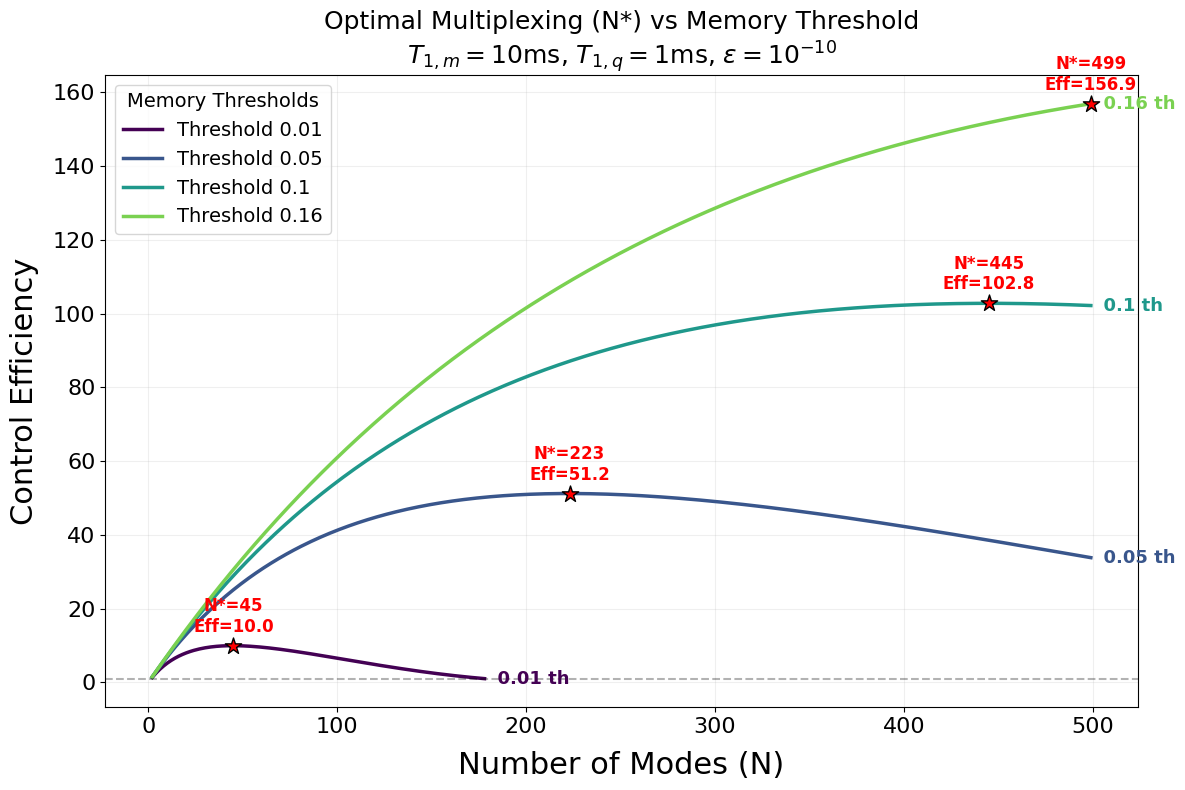

In [25]:
mem_thresholds = [0.01, 0.05, 0.10, 0.16]

label_size = 22
tick_size = 16

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(mem_thresholds)))

for idx, p_m_th in enumerate(mem_thresholds):
    effs = []
    for n in n_range:
        res = analyze_point(vareps, t_log, t_swp, T1_mem, T1_qub, n, p_mem_threshold=p_m_th)
        effs.append(res[0])
    
    effs = np.array(effs)
    mask = effs > 1.0
    
    if np.any(mask):
        valid_ns = n_range[mask]
        valid_effs = effs[mask]
        
        line, = plt.plot(valid_ns, valid_effs, lw=2.5, color=colors[idx], label=f'Threshold {p_m_th}')
        
        plt.text(valid_ns[-1], valid_effs[-1], f'  {p_m_th} th', 
                 color=colors[idx], va='center', fontweight='bold', fontsize=13)
        
        opt_idx = np.nanargmax(valid_effs)
        n_opt = valid_ns[opt_idx]
        max_eff = valid_effs[opt_idx]
        
        plt.scatter(n_opt, max_eff, color='red', marker='*', s=150, zorder=5, edgecolors='black')
        plt.annotate(f'N*={n_opt}\nEff={max_eff:.1f}', 
                     xy=(n_opt, max_eff), 
                     xytext=(0, 10), 
                     textcoords='offset points', 
                     ha='center', fontsize=12, fontweight='bold', color='red')

plt.axhline(1, color='black', linestyle='--', alpha=0.3)
plt.title(f'Optimal Multiplexing (N*) vs Memory Threshold\n$T_{{1,m}}=10$ms, $T_{{1,q}}=1$ms, $\epsilon=10^{{-10}}$', fontsize=18)
plt.xlabel('Number of Modes (N)', fontsize=label_size, labelpad=10)
plt.ylabel('Control Efficiency', fontsize=label_size, labelpad=10)
plt.tick_params(axis='both', labelsize=tick_size)
plt.grid(True, which='both', alpha=0.2)
plt.legend(title="Memory Thresholds", loc='upper left', fontsize=14, title_fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'efficiency_vs_n_thresholds.pdf'), dpi=200, bbox_inches='tight')
plt.show()